# Indonesia AI Usage: Deep Dive

Three focused questions about how Indonesia uses Claude:

1. **Share of global usage** — Indonesia's slice of the worldwide pie, in absolute and per-capita terms
2. **SOC major group composition of top 100 tasks** — what kinds of work, vs. global median and ASEAN peers
3. **Over- and underrepresented request clusters** — bottom-up taxonomy showing what's distinctively Indonesian

**Data:** AEI September 2025 release (already downloaded by prior notebooks).

**ASEAN comparison set:** Singapore, Malaysia, Thailand, Philippines, Vietnam, Brunei, Cambodia, Laos, Myanmar.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from huggingface_hub import hf_hub_download
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

REPO_ID = 'Anthropic/EconomicIndex'
RELEASE = 'release_2025_09_15'
AEI_DIR = Path('./aei_data')
OUTPUT_DIR = Path('./outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

INDONESIA = 'ID'
ASEAN = {
    'BN': 'Brunei', 'KH': 'Cambodia', 'ID': 'Indonesia', 'LA': 'Laos',
    'MY': 'Malaysia', 'MM': 'Myanmar', 'PH': 'Philippines', 'SG': 'Singapore',
    'TH': 'Thailand', 'VN': 'Vietnam',
}
ASEAN_PEERS = [c for c in ASEAN if c != INDONESIA]  # ASEAN excluding Indonesia

# SOC major group labels (US Bureau of Labor Statistics)
SOC_MAJOR_LABELS = {
    '11': 'Management',
    '13': 'Business & Financial',
    '15': 'Computer & Mathematical',
    '17': 'Architecture & Engineering',
    '19': 'Life, Physical & Social Science',
    '21': 'Community & Social Service',
    '23': 'Legal',
    '25': 'Educational Instruction',
    '27': 'Arts, Design, Entertainment',
    '29': 'Healthcare Practitioners',
    '31': 'Healthcare Support',
    '33': 'Protective Service',
    '35': 'Food Preparation',
    '37': 'Building & Grounds Cleaning',
    '39': 'Personal Care & Service',
    '41': 'Sales',
    '43': 'Office & Admin Support',
    '45': 'Farming, Fishing, Forestry',
    '47': 'Construction & Extraction',
    '49': 'Installation, Maintenance, Repair',
    '51': 'Production',
    '53': 'Transportation & Material Moving',
}

print('Setup complete.')

Setup complete.


## Load data

In [2]:
# Ensure files are present
for f in [
    f'{RELEASE}/data/intermediate/aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv',
    f'{RELEASE}/data/intermediate/working_age_pop_2024_country.csv',
    f'{RELEASE}/data/intermediate/onet_task_statements.csv',
]:
    try:
        hf_hub_download(repo_id=REPO_ID, filename=f, repo_type='dataset', local_dir=AEI_DIR)
    except Exception as e:
        print(f'Could not fetch {f}: {e}')

geo = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/aei_raw_claude_ai_2025-08-04_to_2025-08-11.csv')
pop = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/working_age_pop_2024_country.csv')
onet_tasks = pd.read_csv(AEI_DIR / RELEASE / 'data/intermediate/onet_task_statements.csv')

print(f'geo (raw):  {geo.shape}')

# Filter out 'not_classified' from both dimensions
# geo_id='not_classified' -> no country (VPN / missing IP), 15.7% of global usage
# cluster_name='not_classified' -> classifier couldn't categorize the conversation
n_before = len(geo)
geo = geo[geo.geo_id != 'not_classified'].copy()
geo = geo[geo.cluster_name.fillna('').str.lower() != 'not_classified'].copy()
n_after = len(geo)
print(f'geo (clean): {geo.shape}  (removed {n_before - n_after:,} not_classified rows)')

print(f'pop:         {pop.shape}')
print(f'onet_tasks:  {onet_tasks.shape}')

geo (raw):  (100062, 10)
geo (clean): (98656, 10)  (removed 1,406 not_classified rows)
pop:         (194, 5)
onet_tasks:  (19530, 9)


---
## Q1: Indonesia's share of global Claude usage

Three angles:
- **Absolute share** — what % of global Claude.ai usage is Indonesia
- **AUI** — usage share / working-age population share
- **Where Indonesia ranks** in both

In [3]:
# Country-level usage_pct
country_usage = (
    geo[(geo.facet == 'country') & (geo.variable == 'usage_pct')]
    [['geo_id', 'value']].rename(columns={'value': 'usage_pct'})
)
country_count = (
    geo[(geo.facet == 'country') & (geo.variable == 'usage_count')]
    [['geo_id', 'value']].rename(columns={'value': 'usage_count'})
)
country = country_usage.merge(country_count, on='geo_id')

# Add population & AUI
pop_clean = pop[['country_code', 'working_age_pop']].rename(columns={'country_code': 'geo_id'}).dropna()
pop_clean['pop_share'] = 100 * pop_clean.working_age_pop / pop_clean.working_age_pop.sum()
country = country.merge(pop_clean, on='geo_id', how='left')
country['AUI'] = country.usage_pct / country.pop_share

# Headline numbers for Indonesia
id_row = country[country.geo_id == INDONESIA].iloc[0]
n_countries = len(country)
rank_usage = (country.usage_pct > id_row.usage_pct).sum() + 1
rank_aui = (country.AUI > id_row.AUI).sum() + 1

print('=== INDONESIA USAGE (vs global) ===\n')
print(f'Share of global Claude.ai usage:    {id_row.usage_pct:.3f}%')
print(f'Working-age population share:       {id_row.pop_share:.2f}%')
print(f'Anthropic AI Usage Index (AUI):     {id_row.AUI:.3f}')
print(f'  (interpretation: Indonesia uses Claude at {id_row.AUI:.0%} of the rate its population alone would predict)')
print(f'\nRank by absolute usage:  #{rank_usage} of {n_countries} countries')
print(f'Rank by AUI:             #{rank_aui} of {n_countries}')

=== INDONESIA USAGE (vs global) ===

Share of global Claude.ai usage:    1.869%
Working-age population share:       5.08%
Anthropic AI Usage Index (AUI):     0.368
  (interpretation: Indonesia uses Claude at 37% of the rate its population alone would predict)

Rank by absolute usage:  #11 of 172 countries
Rank by AUI:             #113 of 172


In [4]:
# Top 15 countries by usage share — context
top15 = country.nlargest(15, 'usage_pct')[['geo_id', 'usage_pct', 'pop_share', 'AUI']]
top15.columns = ['country', 'global_usage_share_%', 'pop_share_%', 'AUI']
print('Top 15 countries by share of global Claude.ai usage:\n')
print(top15.to_string(index=False))

Top 15 countries by share of global Claude.ai usage:

country  global_usage_share_%  pop_share_%      AUI
     US             21.586448     5.790397 3.727974
     IN              7.150278    26.031006 0.274683
     BR              3.678820     3.862304 0.952494
     JP              3.659743     1.916277 1.909820
     KR              3.658395     0.954704 3.831967
     GB              3.159584     1.152517 2.741465
     DE              2.606859     1.381098 1.887527
     FR              2.209863     1.105272 1.999384
     CA              2.117794     0.706657 2.996922
     AU              1.944336     0.460884 4.218712
     ID              1.869374     5.077366 0.368178
     IT              1.491248     0.984637 1.514516
     TH              1.266882     1.317033 0.961921
     IL              1.134377     0.157465 7.204006
     VN              1.104310     1.798506 0.614015


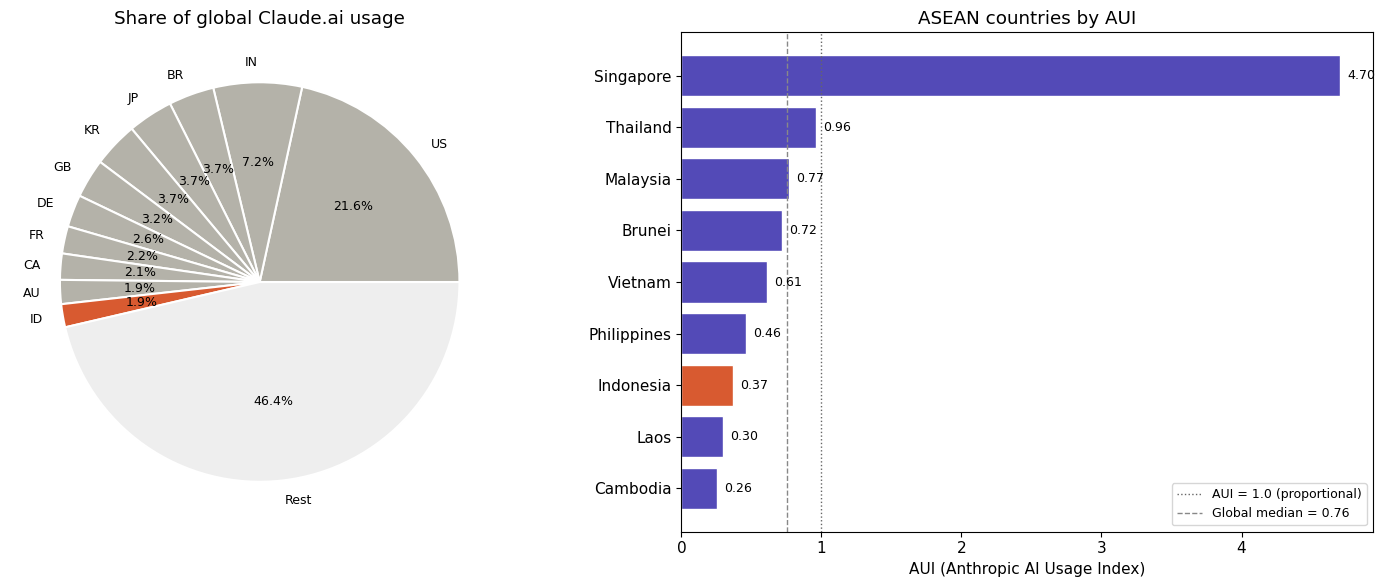

In [8]:
# Visualize: Indonesia's slice of the global pie + ASEAN peers stacked for comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: top 10 + ID + 'Rest of world'
top10 = country.nlargest(10, 'usage_pct').copy()
id_in_top10 = INDONESIA in top10.geo_id.values
if not id_in_top10:
    extra = country[country.geo_id == INDONESIA]
    pie_df = pd.concat([top10, extra])
else:
    pie_df = top10

rest = 100 - pie_df.usage_pct.sum()
labels = pie_df.geo_id.tolist() + ['Rest']
sizes = pie_df.usage_pct.tolist() + [rest]
colors = ['#D85A30' if c == INDONESIA else '#B4B2A9' for c in labels[:-1]] + ['#EEEEEE']
axes[0].pie(sizes, labels=labels, autopct='%.1f%%', colors=colors,
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
            textprops=dict(fontsize=9))
axes[0].set_title('Share of global Claude.ai usage')

# Right: ASEAN comparison
asean_data = country[country.geo_id.isin(ASEAN)].copy()
asean_data['country_name'] = asean_data.geo_id.map(ASEAN)
asean_data = asean_data.sort_values('AUI', ascending=True)

colors_a = ['#D85A30' if c == INDONESIA else '#534AB7' for c in asean_data.geo_id]
bars = axes[1].barh(asean_data.country_name, asean_data.AUI, color=colors_a, edgecolor='white')
axes[1].axvline(1.0, color='#666', linestyle=':', linewidth=1, label='AUI = 1.0 (proportional)')
axes[1].axvline(country.AUI.median(), color='#888', linestyle='--', linewidth=1,
                label=f'Global median = {country.AUI.median():.2f}')
axes[1].set_xlabel('AUI (Anthropic AI Usage Index)')
axes[1].set_title('ASEAN countries by AUI')
axes[1].legend(fontsize=9)
for b, v in zip(bars, asean_data.AUI):
    axes[1].text(v + 0.05, b.get_y() + b.get_height()/2, f'{v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'indonesia_share_and_asean.png', dpi=150, bbox_inches='tight')
plt.show()

country.to_csv(OUTPUT_DIR / 'country_usage_aui.csv', index=False)

---
## Q2: SOC major group composition of top 100 tasks

What kinds of work does Indonesian Claude usage cover, compared to the global median and ASEAN peers?

Steps:
1. For each country, get task-level usage shares
2. Join tasks → SOC codes via O\*NET task statements
3. Aggregate to SOC major group (first 2 digits of SOC code)
4. Compute, for each country, the share of its top-100 tasks that fall into each SOC major group
5. Compare Indonesia vs. global median vs. ASEAN average

In [9]:
# Discover the right variable for onet_task facet
onet_vars = geo[geo.facet == 'onet_task'].variable.unique()
task_pct_var = next(v for v in onet_vars if 'pct' in v.lower())
print(f'Using task variable: {task_pct_var}')

task_usage = (
    geo[(geo.facet == 'onet_task') & (geo.variable == task_pct_var)]
    [['geo_id', 'cluster_name', 'value']]
    .rename(columns={'value': 'usage_pct', 'cluster_name': 'task'})
)

print(f'Total task-country rows: {len(task_usage):,}')
print(f'Unique countries with task data: {task_usage.geo_id.nunique()}')

Using task variable: onet_task_pct
Total task-country rows: 11,878
Unique countries with task data: 147


In [10]:
# Build task -> SOC major group map
task_col = next((c for c in onet_tasks.columns if 'task' in c.lower() and onet_tasks[c].dtype == 'object'), None)
soc_col = next((c for c in onet_tasks.columns if 'onet' in c.lower() or 'soc' in c.lower()), None)

normalize = lambda s: str(s).strip().lower().rstrip('.')
onet_tasks['task_norm'] = onet_tasks[task_col].apply(normalize)
onet_tasks['soc_major'] = onet_tasks[soc_col].astype(str).str[:2]

# Drop dupes — keep one SOC major per task (in practice tasks may map to multiple occupations
# but they almost always share the same major group)
task_to_soc = onet_tasks[['task_norm', 'soc_major']].drop_duplicates('task_norm')

task_usage['task_norm'] = task_usage.task.apply(normalize)
task_usage = task_usage.merge(task_to_soc, on='task_norm', how='left')

match_rate = task_usage.soc_major.notna().mean()
print(f'Task-to-SOC match rate: {match_rate:.0%}')
print(f'Unique SOC major groups present: {task_usage.soc_major.nunique()}')

Task-to-SOC match rate: 99%
Unique SOC major groups present: 22


In [11]:
# For each country, take its top 100 tasks and compute SOC major composition
def top100_soc_composition(country_code, df=task_usage):
    """Return SOC major group share among a country's top 100 tasks (by usage_pct)."""
    sub = df[df.geo_id == country_code].dropna(subset=['soc_major']).copy()
    if len(sub) == 0:
        return None
    top = sub.nlargest(min(100, len(sub)), 'usage_pct')
    composition = top.groupby('soc_major').usage_pct.sum()
    composition = 100 * composition / composition.sum()  # renormalize to top-100 only
    return composition

# Indonesia
id_comp = top100_soc_composition(INDONESIA)

# Global median: compute per-country composition for all countries with enough data, take median per SOC
all_compositions = {}
for c in country.geo_id.unique():
    comp = top100_soc_composition(c)
    if comp is not None and comp.sum() > 0:
        all_compositions[c] = comp

comp_df = pd.DataFrame(all_compositions).T.fillna(0)
global_median = comp_df.median()
print(f'Computed compositions for {len(comp_df)} countries')

# ASEAN peers (excluding Indonesia)
asean_in_data = [c for c in ASEAN_PEERS if c in comp_df.index]
print(f'ASEAN peers in data: {asean_in_data}')
asean_avg = comp_df.loc[asean_in_data].mean()

Computed compositions for 119 countries
ASEAN peers in data: ['KH', 'LA', 'MY', 'PH', 'SG', 'TH', 'VN']


In [12]:
# Build comparison table
comparison = pd.DataFrame({
    'SOC_major': global_median.index,
    'Indonesia_%': [id_comp.get(s, 0) for s in global_median.index],
    'Global_median_%': global_median.values,
    'ASEAN_avg_%': [asean_avg.get(s, 0) for s in global_median.index],
})
comparison['SOC_label'] = comparison.SOC_major.map(SOC_MAJOR_LABELS).fillna(comparison.SOC_major)
comparison['ID_vs_global_pp'] = comparison['Indonesia_%'] - comparison['Global_median_%']
comparison['ID_vs_ASEAN_pp']  = comparison['Indonesia_%'] - comparison['ASEAN_avg_%']
comparison = comparison.sort_values('Indonesia_%', ascending=False)

print('=== SOC MAJOR GROUP COMPOSITION OF TOP 100 TASKS ===\n')
display_cols = ['SOC_label', 'Indonesia_%', 'Global_median_%', 'ASEAN_avg_%', 'ID_vs_global_pp']
print(comparison[display_cols].to_string(index=False, float_format=lambda x: f'{x:6.2f}'))

comparison.to_csv(OUTPUT_DIR / 'soc_composition_comparison.csv', index=False)

=== SOC MAJOR GROUP COMPOSITION OF TOP 100 TASKS ===

                        SOC_label  Indonesia_%  Global_median_%  ASEAN_avg_%  ID_vs_global_pp
          Computer & Mathematical        43.84            69.28        67.66           -25.44
          Educational Instruction        32.82             9.38        13.94            23.44
      Arts, Design, Entertainment        10.39             4.77         6.78             5.62
  Life, Physical & Social Science         4.55             0.00         2.48             4.55
           Office & Admin Support         3.39             7.06         5.49            -3.67
       Community & Social Service         2.00             0.00         0.95             2.00
                       Production         1.32             0.00         0.99             1.32
                       Management         0.69             0.00         0.27             0.69
                            Sales         0.67             0.00         0.68             0.67
      

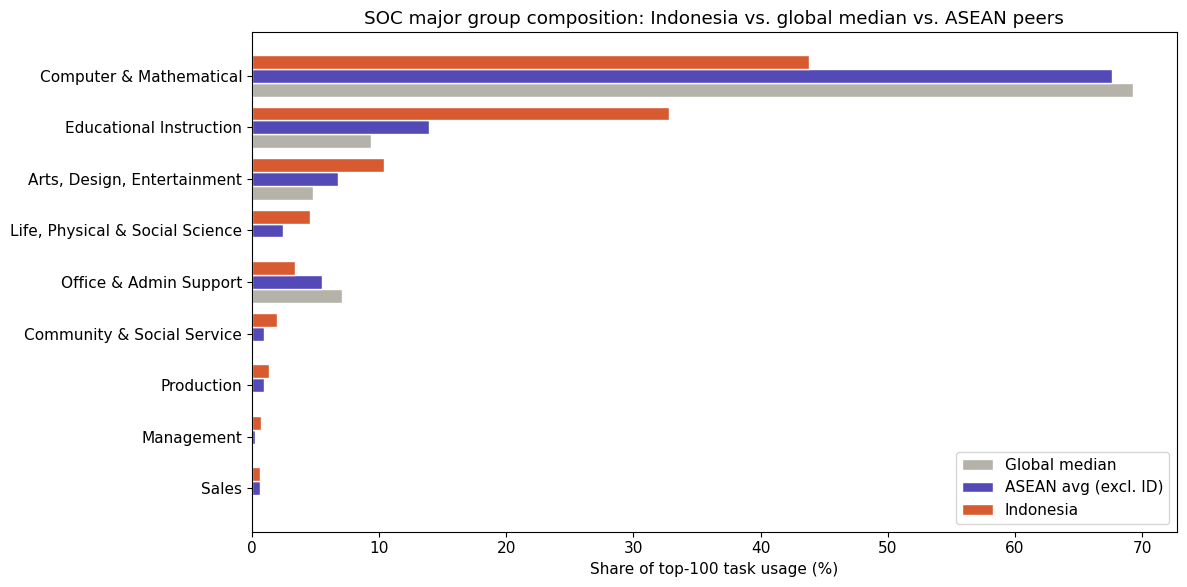

In [13]:
# Visualize: grouped bar chart Indonesia vs Global Median vs ASEAN average
# Show only SOC groups with meaningful share (>0.5% in any of the three)
viz = comparison[
    (comparison['Indonesia_%'] > 0.5) |
    (comparison['Global_median_%'] > 0.5) |
    (comparison['ASEAN_avg_%'] > 0.5)
].sort_values('Indonesia_%', ascending=True)

fig, ax = plt.subplots(figsize=(12, max(6, 0.45 * len(viz))))
y = np.arange(len(viz))
h = 0.27

ax.barh(y - h, viz['Global_median_%'], height=h, label='Global median', color='#B4B2A9', edgecolor='white')
ax.barh(y,     viz['ASEAN_avg_%'],     height=h, label='ASEAN avg (excl. ID)', color='#534AB7', edgecolor='white')
ax.barh(y + h, viz['Indonesia_%'],     height=h, label='Indonesia', color='#D85A30', edgecolor='white')

ax.set_yticks(y)
ax.set_yticklabels(viz.SOC_label)
ax.set_xlabel('Share of top-100 task usage (%)')
ax.set_title('SOC major group composition: Indonesia vs. global median vs. ASEAN peers')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'soc_composition.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Where Indonesia diverges most from global median (positive = Indonesia uses more)
div = comparison.sort_values('ID_vs_global_pp', ascending=False)

print('=== INDONESIA OVER-REPRESENTED in (vs global median) ===\n')
print(div.head(5)[['SOC_label', 'Indonesia_%', 'Global_median_%', 'ID_vs_global_pp']].to_string(index=False, float_format=lambda x: f'{x:6.2f}'))

print('\n=== INDONESIA UNDER-REPRESENTED in (vs global median) ===\n')
print(div.tail(5)[['SOC_label', 'Indonesia_%', 'Global_median_%', 'ID_vs_global_pp']].to_string(index=False, float_format=lambda x: f'{x:6.2f}'))

=== INDONESIA OVER-REPRESENTED in (vs global median) ===

                      SOC_label  Indonesia_%  Global_median_%  ID_vs_global_pp
        Educational Instruction        32.82             9.38            23.44
    Arts, Design, Entertainment        10.39             4.77             5.62
Life, Physical & Social Science         4.55             0.00             4.55
     Community & Social Service         2.00             0.00             2.00
                     Production         1.32             0.00             1.32

=== INDONESIA UNDER-REPRESENTED in (vs global median) ===

              SOC_label  Indonesia_%  Global_median_%  ID_vs_global_pp
     Healthcare Support         0.00             0.00             0.00
   Business & Financial         0.00             0.00             0.00
                  Legal         0.00             0.00             0.00
 Office & Admin Support         3.39             7.06            -3.67
Computer & Mathematical        43.84            69.28

---
## Q3: Request clusters most over- and underrepresented in Indonesia

The `request` facet is Anthropic's bottom-up clustering of conversation topics — different from O\*NET tasks. It captures things like *"web development help"*, *"essay writing assistance"*, *"academic concept explanation"*. This is where Indonesia's coursework tilt should show up most clearly.

**Method:** for each request cluster Indonesia uses, compute its usage share in Indonesia vs. the global median across all countries. Rank by ratio and by percentage-point gap.

In [15]:
# Discover variable for request facet
req_vars = geo[geo.facet == 'request'].variable.unique()
req_pct_var = next(v for v in req_vars if 'pct' in v.lower())
print(f'Using request variable: {req_pct_var}')

request_usage = (
    geo[(geo.facet == 'request') & (geo.variable == req_pct_var)]
    [['geo_id', 'cluster_name', 'value']]
    .rename(columns={'value': 'usage_pct', 'cluster_name': 'request'})
)

print(f'Total request-country rows: {len(request_usage):,}')
print(f'Unique request clusters globally: {request_usage.request.nunique()}')
print(f'Indonesia request clusters:        {request_usage[request_usage.geo_id == INDONESIA].request.nunique()}')

Using request variable: request_pct
Total request-country rows: 24,732
Unique request clusters globally: 703
Indonesia request clusters:        526


In [16]:
# Compute global median per request cluster (across countries that have it)
global_req_stats = (
    request_usage.groupby('request')
    .agg(global_median_pct=('usage_pct', 'median'),
         global_mean_pct=('usage_pct', 'mean'),
         n_countries=('geo_id', 'nunique'))
    .reset_index()
)

# Indonesia's request shares
id_requests = request_usage[request_usage.geo_id == INDONESIA][['request', 'usage_pct']].rename(
    columns={'usage_pct': 'indonesia_pct'}
)

# Join — keep only clusters that exist for both Indonesia and at least 5 other countries
req_gap = id_requests.merge(global_req_stats, on='request', how='inner')
req_gap = req_gap[req_gap.n_countries >= 5].copy()  # require some baseline for the median
req_gap['gap_pp'] = req_gap.indonesia_pct - req_gap.global_median_pct
req_gap['ratio'] = req_gap.indonesia_pct / req_gap.global_median_pct.replace(0, np.nan)

print(f'Request clusters where Indonesia + global median both exist (>=5 countries): {len(req_gap)}')

Request clusters where Indonesia + global median both exist (>=5 countries): 563


In [17]:
# Top OVER-represented (largest positive pp gap, requires meaningful Indonesian share)
over = req_gap[req_gap.indonesia_pct >= 0.1].nlargest(15, 'gap_pp')
print('=== TOP 15 REQUEST CLUSTERS — INDONESIA OVERREPRESENTED ===')
print('(filtered to clusters with >=0.1% Indonesia share to avoid noise)\n')
for _, r in over.iterrows():
    print(f'  +{r.gap_pp:5.2f}pp  ({r.ratio:5.1f}x global)  ID={r.indonesia_pct:.2f}% vs median={r.global_median_pct:.2f}%')
    print(f'                                   {r.request[:100]}')
    print()

=== TOP 15 REQUEST CLUSTERS — INDONESIA OVERREPRESENTED ===
(filtered to clusters with >=0.1% Indonesia share to avoid noise)

  + 4.76pp  (  1.9x global)  ID=10.06% vs median=5.30%
                                   Provide technical and academic assistance across scientific research and educational domains

  + 4.40pp  (  2.2x global)  ID=7.96% vs median=3.56%
                                   Help with academic research, writing, and educational content across multiple disciplines

  + 2.69pp  ( 25.8x global)  ID=2.80% vs median=0.11%
                                   Translate religious and spiritual texts between languages

  + 2.67pp  (  1.4x global)  ID=10.01% vs median=7.33%
                                   Provide educational tutoring and academic assistance across multiple subjects and disciplines

  + 2.59pp  (  2.8x global)  ID=4.06% vs median=1.47%
                                   Create comprehensive K-12 educational materials and teaching resources

  + 2.59pp  (  

In [18]:
# Top UNDER-represented (largest negative pp gap, requires meaningful global presence)
under = req_gap[req_gap.global_median_pct >= 0.2].nsmallest(15, 'gap_pp')
print('=== TOP 15 REQUEST CLUSTERS — INDONESIA UNDERREPRESENTED ===')
print('(filtered to clusters with >=0.2% global median to focus on meaningful global activity)\n')
for _, r in under.iterrows():
    print(f'  {r.gap_pp:6.2f}pp  ({r.ratio:5.2f}x global)  ID={r.indonesia_pct:.2f}% vs median={r.global_median_pct:.2f}%')
    print(f'                                   {r.request[:100]}')
    print()

req_gap.to_csv(OUTPUT_DIR / 'request_cluster_gaps.csv', index=False)

=== TOP 15 REQUEST CLUSTERS — INDONESIA UNDERREPRESENTED ===
(filtered to clusters with >=0.2% global median to focus on meaningful global activity)

   -4.09pp  ( 0.43x global)  ID=3.13% vs median=7.22%
                                   Help develop and debug complete web applications and user interfaces

   -2.69pp  ( 0.85x global)  ID=14.66% vs median=17.35%
                                   Provide comprehensive software development assistance across multiple programming domains and techno

   -1.83pp  ( 0.64x global)  ID=3.23% vs median=5.05%
                                   Provide technical IT support and troubleshooting assistance

   -1.42pp  ( 0.92x global)  ID=15.93% vs median=17.35%
                                   Provide comprehensive software development assistance across multiple programming domains and techno

   -1.18pp  ( 0.78x global)  ID=4.12% vs median=5.30%
                                   Provide technical and academic assistance across scientific resear

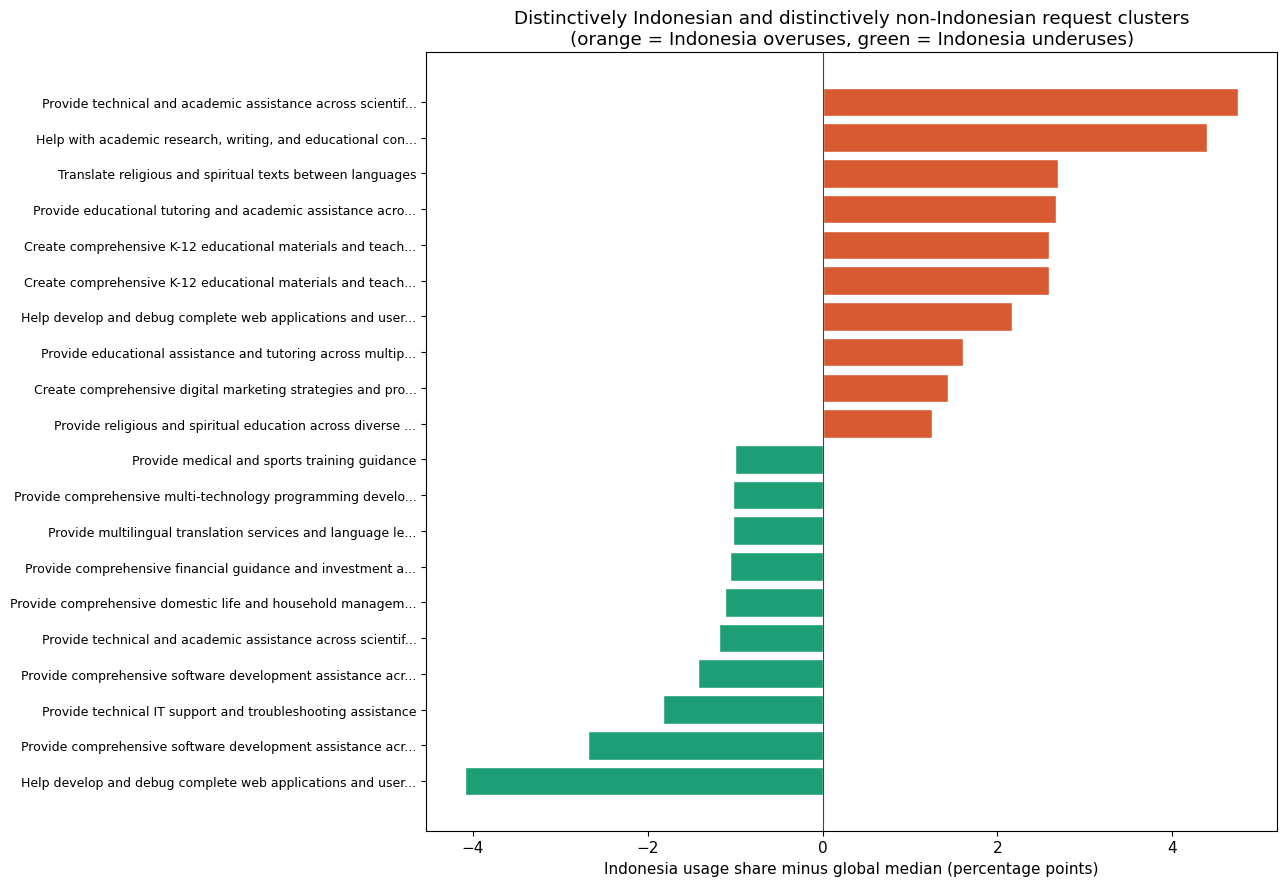

In [19]:
# Visualize: combined under/over chart
fig, ax = plt.subplots(figsize=(13, 9))

top_over = over.head(10).copy()
top_under = under.head(10).copy()
combined = pd.concat([top_under, top_over]).sort_values('gap_pp')

# Truncate long cluster names
combined['short_label'] = combined.request.apply(lambda s: s if len(s) < 60 else s[:57] + '...')

colors = ['#1D9E75' if g < 0 else '#D85A30' for g in combined.gap_pp]
ax.barh(range(len(combined)), combined.gap_pp, color=colors, edgecolor='white')
ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined.short_label, fontsize=9)
ax.axvline(0, color='#444', linewidth=0.8)
ax.set_xlabel('Indonesia usage share minus global median (percentage points)')
ax.set_title('Distinctively Indonesian and distinctively non-Indonesian request clusters\n'
             '(orange = Indonesia overuses, green = Indonesia underuses)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'request_cluster_gaps.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

In [20]:
summary = f'''
INDONESIA AI USAGE — DEEP DIVE FINDINGS
========================================

Q1. SHARE OF GLOBAL CLAUDE.AI USAGE
  - Indonesia: {id_row.usage_pct:.3f}% of global usage
  - Pop share: {id_row.pop_share:.2f}% of working-age population
  - AUI:       {id_row.AUI:.3f}
  - Rank:      #{rank_usage} (usage), #{rank_aui} (AUI) of {n_countries} countries

Q2. SOC MAJOR GROUP COMPOSITION (top 100 tasks)
  Top 3 SOC groups for Indonesia:
{comparison.head(3)[['SOC_label', 'Indonesia_%']].to_string(index=False, header=False, float_format=lambda x: f'{x:5.1f}%')}

  Largest divergence from global median:
    Most over-represented:  {div.iloc[0].SOC_label}  (+{div.iloc[0].ID_vs_global_pp:.1f}pp)
    Most under-represented: {div.iloc[-1].SOC_label}  ({div.iloc[-1].ID_vs_global_pp:.1f}pp)

Q3. REQUEST CLUSTERS
  Most distinctively Indonesian:
    {over.iloc[0].request[:80]}
      ({over.iloc[0].ratio:.1f}x global rate)

  Most missing from Indonesia (vs global):
    {under.iloc[0].request[:80]}
      ({under.iloc[0].ratio:.2f}x global rate)

Files exported:
  outputs/country_usage_aui.csv
  outputs/soc_composition_comparison.csv
  outputs/request_cluster_gaps.csv
  outputs/indonesia_share_and_asean.png
  outputs/soc_composition.png
  outputs/request_cluster_gaps.png
'''
print(summary)
with open(OUTPUT_DIR / 'indonesia_deep_dive_summary.txt', 'w') as f:
    f.write(summary)


INDONESIA AI USAGE — DEEP DIVE FINDINGS

Q1. SHARE OF GLOBAL CLAUDE.AI USAGE
  - Indonesia: 1.869% of global usage
  - Pop share: 5.08% of working-age population
  - AUI:       0.368
  - Rank:      #11 (usage), #113 (AUI) of 172 countries

Q2. SOC MAJOR GROUP COMPOSITION (top 100 tasks)
  Top 3 SOC groups for Indonesia:
    Computer & Mathematical  43.8%
    Educational Instruction  32.8%
Arts, Design, Entertainment  10.4%

  Largest divergence from global median:
    Most over-represented:  Educational Instruction  (+23.4pp)
    Most under-represented: Computer & Mathematical  (-25.4pp)

Q3. REQUEST CLUSTERS
  Most distinctively Indonesian:
    Provide technical and academic assistance across scientific research and educati
      (1.9x global rate)

  Most missing from Indonesia (vs global):
    Help develop and debug complete web applications and user interfaces
      (0.43x global rate)

Files exported:
  outputs/country_usage_aui.csv
  outputs/soc_composition_comparison.csv
  outp